In [10]:
import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt

# use the downloaded data from the data/raw folder
fastf1.Cache.enable_cache('../data/raw')

# fastf1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme=fastf1)
fastf1.plotting.setup_mpl(mpl_timedelta_support=True)

In [11]:
# load one of the races
session = fastf1.get_session(2025, 'Bahrain', 'R')
session.load()

# get the fastest lap
fastest_lap = session.laps.pick_fastest()

# get the telemetry from that lap
telemetry = fastest_lap.get_car_data().add_distance()
print(telemetry.columns)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '63', '4', '16', '44', '1', '10', '31', '22', '87', '12', '23', '6', '7', '14', '30', '18', '5', '55', '27']


Index(['Date', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source',
       'Time', 'SessionTime', 'Distance'],
      dtype='object')


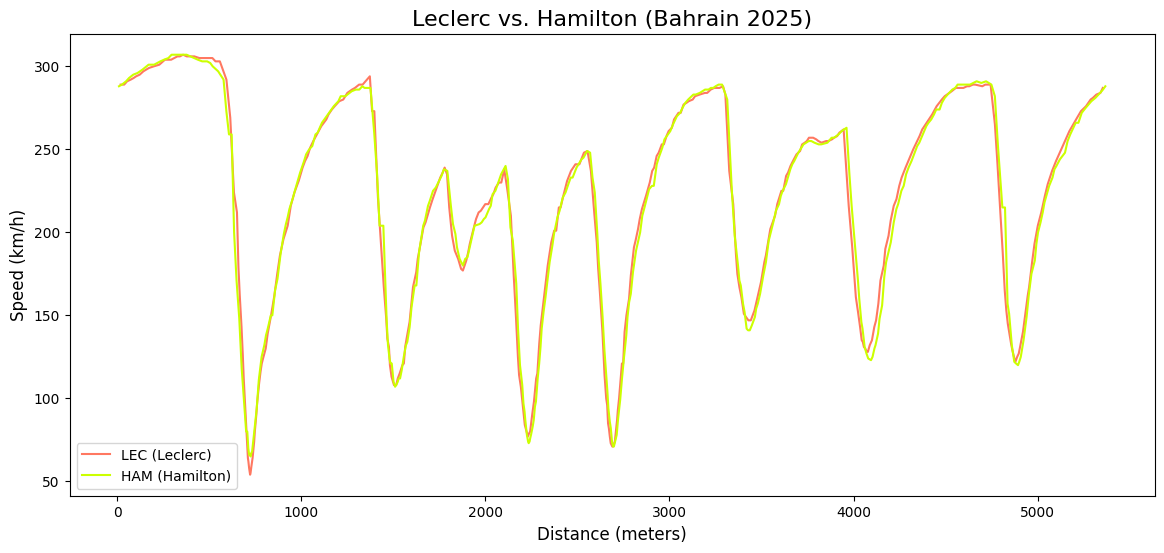

In [12]:
# pick fastest lap from both ferrari drivers
lap_lec = session.laps.pick_drivers('LEC').pick_fastest()
lap_ham = session.laps.pick_drivers('HAM').pick_fastest()

# get the car telemetry
tel_lec = lap_lec.get_car_data().add_distance()
tel_ham = lap_ham.get_car_data().add_distance()

fig, ax = plt.subplots(figsize=(14, 6))

# plot leclerc
ax.plot(tel_lec['Distance'], tel_lec['Speed'], 
        color="#FF26009E", label='LEC (Leclerc)')

# plot hamilton
ax.plot(tel_ham['Distance'], tel_ham['Speed'], 
        color='#CCFF00', label='HAM (Hamilton)')

ax.set_xlabel('Distance (meters)', fontsize=12)
ax.set_ylabel('Speed (km/h)', fontsize=12)
ax.set_title("Leclerc vs. Hamilton (Bahrain 2025)", fontsize=16)
ax.legend()

plt.show()